In [61]:

import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [62]:
import matplotlib.pyplot as plt

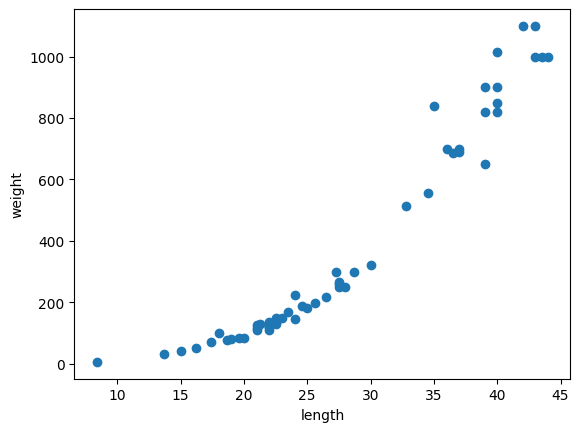

In [63]:
plt.scatter(perch_length,perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [64]:
len(perch_length)

56

In [65]:
len(perch_weight)

56

In [66]:
# fish_data=[[l,w] for l,w in zip(perch_length,perch_weight)]
# fish_target=[1]*35 + [0]*14
# len(fish_length)

In [67]:
from sklearn.model_selection import train_test_split
train_input,test_input, train_target,test_target=train_test_split(perch_length,perch_weight, random_state=42)

# kn.fit(train_input,train_target)

In [68]:
train_input.shape, test_input.shape

((42,), (14,))

In [69]:
#1차원배열이라 2차원 배열로바꾸어야 함. 
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [70]:
#1차원배열 2차로 바꾸는 연습
test_array=np.array([1,2,3,4])
test_array.shape

(4,)

In [71]:
#1차원배열 2차로 바꾸는 연습
test_array=test_array.reshape(2,2)
test_array.shape

(2, 2)

In [72]:
test_array

array([[1, 2],
       [3, 4]])

In [73]:
# 2차원으로
train_input=train_input.reshape(-1,1) #1열로 만들고 나머지는 알아서 해줘.
test_input=test_input.reshape(-1,1)

In [74]:
train_input
test_input

array([[ 8.4],
       [18. ],
       [27.5],
       [21.3],
       [22.5],
       [40. ],
       [30. ],
       [24.6],
       [39. ],
       [21. ],
       [43.5],
       [16.2],
       [28. ],
       [27.3]])

In [75]:
train_input.shape, test_input.shape

((42, 1), (14, 1))

# KNN회귀 모델 만들기

In [76]:
from sklearn.neighbors import KNeighborsRegressor

knr=KNeighborsRegressor()
knr.fit(train_input,train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 모델평가
- 결정계수 (R²)

In [77]:
knr.score(test_input,test_target)
#회귀는 정답이 없으므로 결정계수가 평가한다.
#예측에 타깃에 아주 가까워지면 분자가 0에 가까워지므로 1에 가까운 값이 된다.
#1에 가까우므로 아주 좋은 결과가 나왔다고 할 수 있다. 


0.992809406101064

# 예측하기


In [78]:
test_prediction=knr.predict(test_input)
test_prediction

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [79]:
#정답
test_target

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

In [80]:
#score()의 0.99는 정답과 거의 동일이 아님
#KNeighborsRegressor.score()는 정확도가 아니라 R제금입니다. 
#분자:예측오차(제곱합)
#분모:타깃값 자체가 원래 얼마나 퍼져있는지(전체분사)
#즉,타겟갑 범위가 엄청넓으며(예:5~1000)
#몇개가 좀 틀려도 전체 분산에 비해 오차가 작게 보일수 있음
#지금 예측값이 "이상한 이유"(KNN의 평균 특성)
#이건KNN이 가까운 웃들의 평균으로 예측하기 때문이다.

# 오차가 얼마야?


In [81]:
from sklearn.metrics import mean_absolute_error
#테스트 세트에 대한 평균 절댓갑 오차를 계산합니다. 
mean_absolute_error(test_target,test_prediction)

19.157142857142862

# 과대적합 vs 과소적합

In [82]:
knr.score(train_input,train_target)

0.9698823289099254

In [83]:
knr.score(test_input,test_target)

0.992809406101064

#훈련세트의 점수가 낮고 테스트 세트의 점수가 더 높으므로 훈련세트에 과소적합되었다고 볼 수 있다.

#이웃수 K조정하기


In [84]:
#이웃의 갯수를 3으로 설정합니다.
knr.n_neighbors=3
#모델을 다시 훈련합니다.
knr.fit(train_input,train_target)
knr.score(train_input,train_target)

0.9804899950518966

In [85]:
knr.score(test_input,test_target)

0.9746459963987609

# 최근접 이웃 확인하기

In [86]:
distances, indexes=knr.kneighbors([[15]])
distances, indexes

(array([[0. , 1.3, 2.4]]), array([[25, 23,  3]]))

### 문제 1

길이 20cm 물고기의 무게를 예측하시오.

### 문제 2

K=1, K=5일 때 예측값 차이를 비교하시오.

### 문제 3

이웃 데이터가 무엇인지 출력해보시오.

In [87]:
test_prediction2=knr.predict([[20]])
test_prediction2

array([95.])

In [88]:

knr.n_neighbors=1

knr.fit(train_input,train_target)
knr.score(train_input,train_target)

0.9852830341215901

In [89]:
knr.score(test_input,test_target)

0.991309195814175

In [90]:
knr.n_neighbors=5
knr.fit(train_input,train_target)
knr.score(train_input,train_target)

0.9698823289099254

In [91]:
knr.score(test_input,test_target)

0.992809406101064

In [102]:
distances, indexes=knr.kneighbors([[20]])
distances, indexes

(array([[0. , 0.4, 1. , 1. , 1. ]]), array([[10,  0, 36, 31, 17]]))

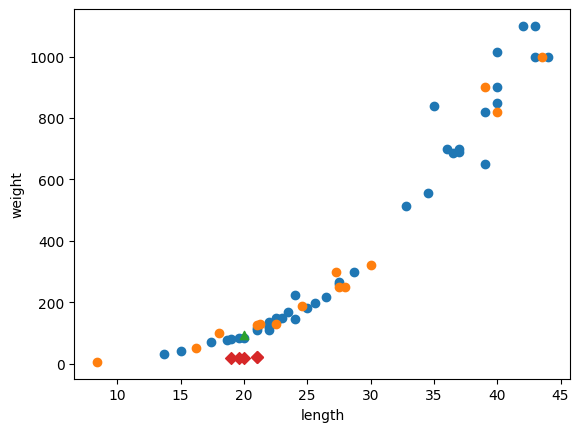

In [103]:
plt.scatter(train_input,train_target)
plt.scatter(test_input,test_target)
plt.scatter(20, 95, marker='^') 
plt.scatter(train_input[indexes],train_input[indexes],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()
